# 07 — FIFO inventory for short-life retail products

This tutorial asks a practical question: **how do replenishment targets and shelf life interact?**

We use 20 demand series from a local prepared sample of the M5 data. M5 contributes only item identifiers, dates, and observed unit demand. The inventory, lot ages, lead time, policies, shelf lives, and normalized costs below are hypothetical teaching assumptions. The selected items are not claimed to be perishable products.

The comparison has four forecast-derived strategies—ETS-90, ETS-95, ARIMA-90, and ARIMA-95—and one simple history-rate baseline. Each runs with a 3-, 5-, and 8-day shelf life.

In [2]:
import math
from importlib.metadata import version
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from smooth import ES, MSARIMA

from stockcast import (
    FixedPeriodicReviewTargets, InventoryStateDataFrame,
    OrderUpToPolicy, PeriodicReviewPolicy,
)
from stockcast.core import ShelfLifeEngine
from stockcast.evaluation import (
    InventoryEvaluator, avg_inventory_position, avg_on_hand, avg_on_order,
    cost_per_demand_unit, demand_period_service_level, fill_rate,
    holding_cost, lost_sales_units, order_event_count, order_units,
    ordering_cost, peak_ending_on_hand, purchase_cost, shortage_cost,
    sku_order_line_count, terminal_pipeline_units, total_cost, waste_cost,
)

%matplotlib inline
print(f"Smooth {version('smooth')} | Stockcast source checkout")

Smooth 1.0.7 | Stockcast source checkout


## 1. Load the prepared M5 sample

The CSV is a local, user-supplied sample; Stockcast does not distribute it. It is already in the long shape needed here: one row per `unique_id` and `date`, with observed demand in `y`. The category columns are descriptive M5 identifiers, not inventory facts.

Set `data_path` directly to another prepared copy if yours lives elsewhere.

In [3]:
# Run from the repository root so this committed example asset is available.
data_path = Path("examples/notebooks/data/m5/sample_1.csv")
# Parse dates now so later filtering and plotting use real timestamps.
data = pd.read_csv(data_path, parse_dates=["date"])

# Keep the preview small: we only need to see the available columns and values.
print(f"{data['unique_id'].nunique()} items from "
      f"{data['date'].min().date()} to {data['date'].max().date()}")
data.head()


100 items from 2011-01-29 to 2016-04-24


,unique_id,date,y,cat_id,dept_id,store_id,state_id
0,FOODS_1_001_CA_1,2011-01-29,3,FOODS,FOODS_1,CA_1,CA
1,FOODS_1_001_CA_1,2011-01-30,0,FOODS,FOODS_1,CA_1,CA
2,FOODS_1_001_CA_1,2011-01-31,0,FOODS,FOODS_1,CA_1,CA
3,FOODS_1_001_CA_1,2011-02-01,1,FOODS,FOODS_1,CA_1,CA
4,FOODS_1_001_CA_1,2011-02-02,4,FOODS,FOODS_1,CA_1,CA


## 2. Choose 20 items using history only

We use the 180 days through 28 February 2016 as model history and the following 56 days as held-out demand. To obtain active series without looking at the holdout, items are ranked by:

1. number of history days with positive demand;
2. total history demand;
3. item identifier as a deterministic tie-breaker.

The first 7 holdout days warm up the simulation, the next 42 are scored, and the last 7 settle outstanding orders.

In [4]:
# The origin is the final date visible to item selection and model fitting.
forecast_origin = pd.Timestamp("2016-02-28")
history_days, holdout_days = 180, 56
# Include the origin in the 180 history days; start demand on the next day.
history_start = forecast_origin - pd.Timedelta(days=history_days - 1)
holdout_start = forecast_origin + pd.Timedelta(days=1)
holdout_end = forecast_origin + pd.Timedelta(days=holdout_days)

# This pool is the only data used to rank items and initialize the experiment.
history_pool = data[data["date"].between(history_start, forecast_origin)]

In [5]:
# Rank only with observations available at the forecast origin.
# Frequent positive demand gives the FIFO example enough inventory movement to inspect.
ranking = (history_pool.groupby("unique_id")["y"]
           .agg(positive_days=lambda x: (x > 0).sum(), total_units="sum")
           .reset_index()
           .sort_values(["positive_days", "total_units", "unique_id"],
                        ascending=[False, False, True]))
selected_items = ranking.head(20)["unique_id"].tolist()

# Use the same selected item list for model history and realized holdout demand.
history = history_pool[history_pool["unique_id"].isin(selected_items)].copy()
holdout = data[data["unique_id"].isin(selected_items)
               & data["date"].between(holdout_start, holdout_end)].copy()
holdout = holdout.sort_values(["unique_id", "date"])
# Stockcast uses a zero-based period number to align demand with decisions and receipts.
holdout["period"] = holdout.groupby("unique_id").cumcount()
holdout = holdout[["unique_id", "date", "period", "y"]]

print("Selected items:")
print(pd.Series(selected_items).to_string(index=False, header=False))
# Twenty items share 180 history days and 56 holdout days each: complete grids.
assert history.groupby("unique_id").size().eq(180).all()
assert holdout.groupby("unique_id").size().eq(56).all()
assert holdout["date"].min() == holdout_start


Selected items:
FOODS_1_085_CA_1
FOODS_1_018_CA_1
FOODS_1_082_CA_1
FOODS_1_046_CA_1
FOODS_1_099_CA_1
FOODS_1_012_CA_1
FOODS_1_087_CA_1
FOODS_1_074_CA_1
FOODS_1_032_CA_1
FOODS_1_043_CA_1
FOODS_1_083_CA_1
FOODS_1_064_CA_1
FOODS_1_042_CA_1
FOODS_1_054_CA_1
FOODS_1_067_CA_1
FOODS_1_004_CA_1
FOODS_1_097_CA_1
FOODS_1_005_CA_1
FOODS_1_040_CA_1
FOODS_1_094_CA_1


Four preselected series give a readable view of the demand scale and intermittency. The dashed line separates model history from held-out demand; no logarithmic transform is used.

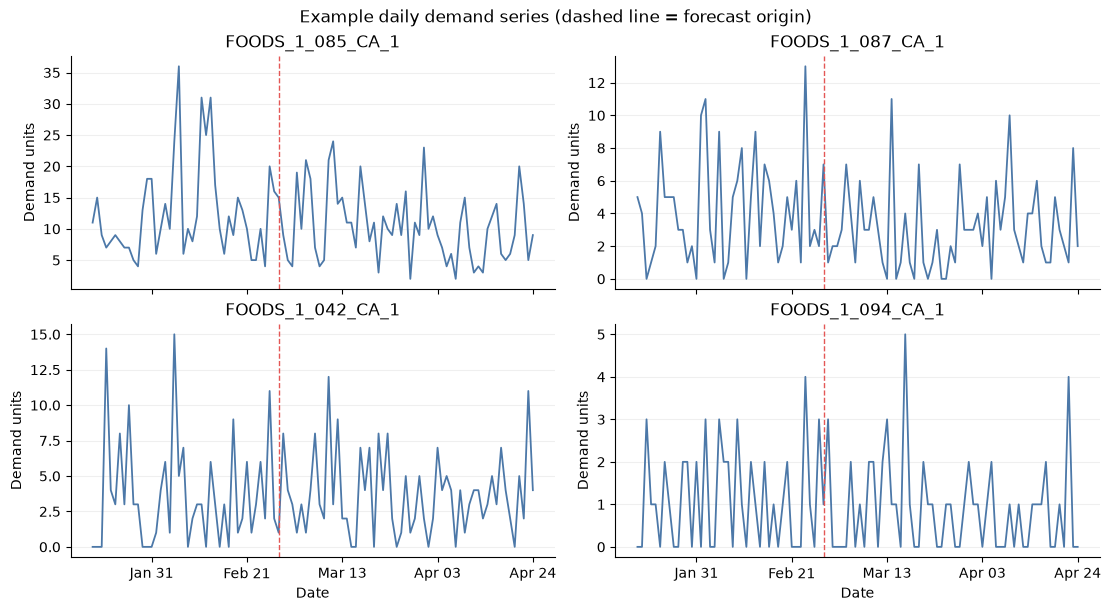

In [6]:
# Fixed selection ranks give examples across the activity ranking without using outcomes.
sample_items = [selected_items[i] for i in [0, 6, 12, 19]]
# Show recent history beside the complete holdout so the origin is easy to see.
plot_data = data[data["unique_id"].isin(sample_items)
                 & data["date"].between(forecast_origin - pd.Timedelta(days=41),
                                        holdout_end)]

fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True, layout="constrained")
# One panel per item keeps their different demand scales readable.
for ax, item in zip(axes.flat, sample_items):
    series = plot_data[plot_data["unique_id"].eq(item)]
    ax.plot(series["date"], series["y"], color="#4C78A8", lw=1.3)
    ax.axvline(forecast_origin, color="#E45756", ls="--", lw=1)
    ax.set(title=item, ylabel="Demand units")
    ax.grid(axis="y", alpha=.2)
    ax.spines[["top", "right"]].set_visible(False)
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=21))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
for ax in axes[-1]:
    ax.set_xlabel("Date")
fig.suptitle("Example daily demand series (dashed line = forecast origin)")
plt.show()

## 3. Turn forecast uncertainty into inventory targets

All forecast branches use the same daily timing: a 2-day lead time and review every 2 days. The protection horizon is therefore 4 days.

- **ETS:** Smooth `ES(model="ANN")`, an additive-error, no-trend, no-seasonality model.
- **ARIMA:** Smooth `MSARIMA(1,0,1, constant=True)`.
- **Targets:** direct one-sided upper prediction bounds for *cumulative four-day demand* at 90% and 95%.

`cumulative=True` is important: it asks Smooth for uncertainty in the four-day total. We neither add daily quantiles nor use point forecasts as protection targets. Because orders are in whole units, the direct bound is rounded upward with `ceil`; the unrounded value is retained beside it.

In [7]:
# An order must cover demand until the next review order can arrive.
lead_time, review_period = 2, 2
protection_horizon = lead_time + review_period
target_probabilities = [0.90, 0.95]
# Store the end date so Stockcast can verify what period each target represents.
target_end_date = forecast_origin + pd.Timedelta(days=protection_horizon)

In [8]:
target_rows = []
for item in selected_items:
    # Smooth expects one ordered numeric series for each item.
    y = (history[history["unique_id"].eq(item)]
         .sort_values("date")["y"].astype(float).reset_index(drop=True))

    # Fresh model objects keep every item fit independent.
    for model_name, model in {
        "ETS": ES(model="ANN"),
        "ARIMA": MSARIMA(ar_order=1, i_order=0, ma_order=1, constant=True),
    }.items():
        model.fit(y)
        for probability in target_probabilities:
            # `cumulative=True` returns one bound for total four-day demand.
            forecast = model.predict(
                h=protection_horizon, interval="prediction",
                level=probability, side="upper", cumulative=True,
            )
            # Retain Smooth's value, then round up for whole-unit ordering.
            raw_target = float(forecast.upper.iloc[0, 0])
            target_rows.append({
                "unique_id": item, "model": model_name,
                "probability": probability, "raw_target": raw_target,
                "target_units": float(math.ceil(raw_target)),
                "target_end_date": target_end_date,
            })

targets = pd.DataFrame(target_rows)

In [9]:
# Twenty items times two models times two probabilities give eighty targets.
assert len(targets) == 20 * 2 * 2

# A small slice makes the 90% versus 95% protection visible.
target_view = (targets[targets["unique_id"].isin(selected_items[:5])]
               .assign(strategy=lambda x: x["model"] + "-" +
                       (100 * x["probability"]).astype(int).astype(str))
               # Pivot only for presentation; policy fitting continues to use the long table.
               .pivot(index="unique_id", columns="strategy", values="target_units"))
print(target_view.to_string())


strategy          ARIMA-90  ARIMA-95  ETS-90  ETS-95
unique_id                                           
FOODS_1_018_CA_1      47.0      52.0    50.0    54.0
FOODS_1_046_CA_1      40.0      44.0    42.0    46.0
FOODS_1_082_CA_1      46.0      50.0    50.0    53.0
FOODS_1_085_CA_1      64.0      69.0    69.0    74.0
FOODS_1_099_CA_1      65.0      71.0    67.0    72.0


## 4. Configure comparable replenishment rules

The four forecast branches all use the same periodic order-up-to `(R,S)` policy. Only the model and target probability change.

The non-forecast baseline sets `S = ceil(4 × trailing 28-day mean demand)`. It reviews and restores stock to `S` with no fitted model and no probabilistic interpretation. This history-only formula is an experimental heuristic, not an M5 field.

In [10]:
policies = {}
for model_name in ["ETS", "ARIMA"]:
    for probability in target_probabilities:
        strategy = f"{model_name}-{int(100 * probability)}"
        # Give each policy exactly one target per item for its model/probability pair.
        model_targets = targets[(targets["model"].eq(model_name))
                                & (targets["probability"].eq(probability))]
        # All four branches share timing and policy family for a fair contrast.
        policies[strategy] = OrderUpToPolicy(
            lead_time=lead_time, review_period=review_period,
            service_level=probability, allow_backorders=False,
        ).fit(
            model_targets, target_column="target_units",
            target_probability=probability,
            protection_horizon=protection_horizon,
            # Stockcast executes the target; Smooth remains its declared source.
            target_source="external_direct", forecast_origin=forecast_origin,
            forecast_frequency="D", target_end_date_column="target_end_date",
        )

In [11]:
# The baseline uses only the final 28 history days.
recent_history = history[history["date"] > forecast_origin - pd.Timedelta(days=28)]
recent_mean = recent_history.groupby("unique_id")["y"].mean().reindex(selected_items)
# Four mean-demand days match the forecast branches' protection horizon.
baseline_level = np.ceil(protection_horizon * recent_mean).astype(float)

# Set s = S: at an eligible review, restore inventory position to this level.
baseline_provider = FixedPeriodicReviewTargets(
    reorder_point=baseline_level.to_dict(),
    order_up_to_level=baseline_level.to_dict(),
)
# This uses a policy target provider, not a fitted forecasting model.
policies["History-rate baseline"] = PeriodicReviewPolicy(
    lead_time=lead_time, review_period=review_period,
    service_level=0.95, allow_backorders=False,
).fit(
    pd.DataFrame({"unique_id": selected_items}),
    target_provider=baseline_provider,
    information_origin=forecast_origin, information_frequency="D",
)

`PeriodicReviewPolicy` requires a `service_level` label, so the baseline carries `0.95` as policy metadata. It is **not** a 95% forecast target or promised service level; its actual target is the history-rate formula shown above.

## 5. Create opening stock and dated lots

Opening on-hand is `max(3, ceil(2 × trailing 28-day mean))`, using history only. This is another experimental initialization heuristic. Each item's quantity is split across lots received 2, 1, and 0 days before the forecast origin: 20%, 30%, and the remaining whole units. The lot quantities add exactly to opening on-hand.

In [12]:
# Two mean-demand days mirror lead-time coverage; three units allow three dated lots.
opening_units = np.maximum(3, np.ceil(lead_time * recent_mean)).astype(int)
opening_stock = pd.DataFrame({
    "unique_id": selected_items,
    "observed_on_hand": opening_units.to_numpy(),
})
opening_stock


,unique_id,observed_on_hand
0,FOODS_1_085_CA_1,28
1,FOODS_1_018_CA_1,20
2,FOODS_1_082_CA_1,17
3,FOODS_1_046_CA_1,13
4,FOODS_1_099_CA_1,25
5,FOODS_1_012_CA_1,7
6,FOODS_1_087_CA_1,10
7,FOODS_1_074_CA_1,5
8,FOODS_1_032_CA_1,8
9,FOODS_1_043_CA_1,3


In [13]:
# Initialize Stockcast's inventory state from the history-based on-hand values.
opening_inventory = InventoryStateDataFrame(
    selected_items, max_lead_time=lead_time, allow_backorders=False,
).initialize_from_observed(
    opening_stock, on_hand_column="observed_on_hand", start_date=forecast_origin,
)
opening_inventory


InventoryStateDataFrame(n_skus=20, total_on_hand=177, total_safety_stock=0, total_backorders=0, has_stockout=False, has_backorder=False)

In [14]:
opening_lot_rows = []
for item, quantity in opening_units.items():
    # Allocate the first two ages, then use the residual to preserve the exact total.
    oldest = max(1, math.floor(0.20 * quantity))
    middle = max(1, math.floor(0.30 * quantity))
    newest = quantity - oldest - middle
    # `received_date` is the lot date used later by FIFO ageing and expiry.
    for age, lot_quantity in [(2, oldest), (1, middle), (0, newest)]:
        opening_lot_rows.append({
            "unique_id": item,
            "received_date": forecast_origin - pd.Timedelta(days=age),
            "quantity": lot_quantity,
        })

opening_lots = pd.DataFrame(opening_lot_rows)
# Three items are enough to make the lot construction concrete.
print(opening_lots[opening_lots["unique_id"].isin(selected_items[:3])].to_string(index=False))

       unique_id received_date  quantity
FOODS_1_085_CA_1    2016-02-26         5
FOODS_1_085_CA_1    2016-02-27         8
FOODS_1_085_CA_1    2016-02-28        15
FOODS_1_018_CA_1    2016-02-26         4
FOODS_1_018_CA_1    2016-02-27         6
FOODS_1_018_CA_1    2016-02-28        10
FOODS_1_082_CA_1    2016-02-26         3
FOODS_1_082_CA_1    2016-02-27         5
FOODS_1_082_CA_1    2016-02-28         9


## 6. Run the shelf-life scenarios

The engine accepts one shelf-life duration per run, so 3, 5, and 8 days are separate scenarios—not fabricated per-item settings. In each daily step:

1. lots whose age reaches the shelf life expire **before demand**;
2. arriving replenishment becomes a newly dated lot;
3. fulfilled demand consumes the oldest eligible lots first (FIFO);
4. unmet demand is lost rather than backordered.

We score days 8–49. The final 7 days allow pipeline settlement and place no new orders.

Normalized costs are hypothetical: 0.02 per ending unit-day held, 2.00 per lost unit, 0.50 per positive SKU order line, 1.00 per ordered unit purchased, and 0.25 per expired unit. M5 supplied none of these prices, margins, fees, or penalties.

In [15]:
# Shelf life is global within one engine run, so each duration is a separate scenario.
shelf_lives = {"3 days": 3, "5 days": 5, "8 days": 8}
warmup_periods, scoring_periods, settlement_periods = 7, 42, 7
# The evaluator activates only the five normalized components named here.
cost_context = {
    "cost_components": ["holding", "shortage", "ordering", "purchase", "waste"],
    "holding_cost_per_unit_period": 0.02,
    "shortage_cost_per_unit": 2.00,
    "order_cost_per_sku_line": 0.50,
    "order_cost_per_unit": 0.00,
    "purchase_cost_per_unit": 1.00,
    "waste_cost_per_unit": 0.25,
}

In [16]:
results = {}
# Cross every shelf-life assumption with the same five strategy definitions.
for shelf_name, shelf_days in shelf_lives.items():
    for strategy, policy in policies.items():
        # A fresh engine makes the global shelf-life setting explicit for this run.
        results[(shelf_name, strategy)] = ShelfLifeEngine(
            shelf_life_days=shelf_days,
        ).run(
            policy=policy, demand_source=holdout, inventory=opening_inventory,
            n_periods=holdout_days, period_frequency="D",
            # Decide at opening, then score only after the seven-day warm-up.
            initial_decision="none",
            warmup_periods=warmup_periods, scoring_periods=scoring_periods,
            # Settlement receives existing pipeline but deliberately places no new orders.
            settlement_periods=settlement_periods, order_during_settlement=False,
            demand_source_name="local prepared M5 sample holdout",
            random_seed=None, opening_lots=opening_lots,
            opening_expiry_handling="reject",
        )

print(f"Completed {len(results)} strategy × shelf-life runs.")

Completed 15 strategy × shelf-life runs.


The event ledger keeps expiry distinct from demand depletion and shortage. Here are the first eight days for one item under ETS-95 and the 3-day shelf life. `expired_units` leaves stock before that day's demand; `received_units` records newly dated arrivals.

In [17]:
# Select ranks before inspecting results so examples are not outcome-picked.
representative_items = [selected_items[0], selected_items[10], selected_items[19]]
example_events = results[("3 days", "ETS-95")].to_event_frame(window="all")
# Period rows contain daily physical flows; other event types carry different evidence.
example_events = (example_events.query(
    "event_type == 'period' and unique_id == @representative_items[1]"
).sort_values("date").head(8))

event_columns = [
    "date", "demand", "received_units", "order_quantity",
    "expired_units", "ending_on_hand", "shortage_units",
]
print(example_events[event_columns].to_string(index=False))

      date  demand  received_units  order_quantity  expired_units  ending_on_hand  shortage_units
2016-02-29     0.0             0.0            14.0            1.0             4.0             0.0
2016-03-01     3.0             0.0             0.0            1.0             0.0             0.0
2016-03-02     2.0            14.0             4.0            0.0            12.0             0.0
2016-03-03     2.0             0.0             0.0            0.0            10.0             0.0
2016-03-04     0.0             4.0             4.0            0.0            14.0             0.0
2016-03-05     2.0             0.0             0.0           10.0             2.0             0.0
2016-03-06     2.0             4.0            12.0            0.0             4.0             0.0
2016-03-07     3.0             0.0             0.0            0.0             1.0             0.0


## 7. Evaluate the scoring window

`InventoryEvaluator` reads the validated event rows produced by each run. Portfolio metrics below are explicitly pooled across all 20 items. Fill rate is fulfilled units divided by demand; demand-period service is the share of item-days without shortage.

Waste rate needs a denominator with a clear physical meaning. We define it as `expired / (expired + fulfilled)`: the share of physical stock outflow that expired rather than serving demand.

In [18]:
# Custom evaluator metrics accept the event frame and the shared metric context.
def expired_units(event_frame, context):
    rows = event_frame[event_frame["event_type"].eq("period")]
    return float(rows["expired_units"].sum())


def waste_outflow_rate(event_frame, context):
    rows = event_frame[event_frame["event_type"].eq("period")]
    expired = float(rows["expired_units"].sum())
    fulfilled = float(rows["fulfilled_units"].sum())
    # Both terms are physical stock outflows, which makes this rate interpretable.
    physical_outflow = expired + fulfilled
    return expired / physical_outflow if physical_outflow else 0.0

In [19]:
portfolio_rows, item_rows = [], []
# Portfolio metrics are pooled across all items, not averaged item percentages.
portfolio_metrics = [
    fill_rate, demand_period_service_level, lost_sales_units,
    avg_on_hand, peak_ending_on_hand, avg_on_order, avg_inventory_position,
    order_units, sku_order_line_count, order_event_count,
    expired_units, waste_outflow_rate, holding_cost, shortage_cost,
    ordering_cost, purchase_cost, waste_cost, total_cost,
    cost_per_demand_unit, terminal_pipeline_units,
]
# A shorter item-level set is enough to reveal heterogeneity without a huge table.
item_metrics = [
    fill_rate, demand_period_service_level, lost_sales_units,
    avg_on_hand, order_units, expired_units, waste_outflow_rate, total_cost,
]

for (shelf_name, strategy), result in results.items():
    # Fit to the scoring window so warm-up and settlement cannot enter the metrics.
    evaluator = InventoryEvaluator().fit(result, window="scoring")
    # An empty grouping list requests one pooled portfolio row.
    row = evaluator.evaluate(portfolio_metrics, groupby=[], context=cost_context).iloc[0]
    portfolio_rows.append({**row.to_dict(), "shelf_life": shelf_name, "strategy": strategy})

    # Grouping by identifier keeps one metric row per selected item.
    by_item = evaluator.evaluate(item_metrics, groupby=["unique_id"], context=cost_context)
    by_item["shelf_life"], by_item["strategy"] = shelf_name, strategy
    item_rows.append(by_item)

portfolio = pd.DataFrame(portfolio_rows)
by_item = pd.concat(item_rows, ignore_index=True)

In [20]:
# Present the measures needed for interpretation and keep the full metric frame available.
summary_columns = [
    "shelf_life", "strategy", "fill_rate", "demand_period_service_level",
    "lost_sales_units", "avg_on_hand", "order_units", "expired_units",
    "waste_outflow_rate", "total_cost", "cost_per_demand_unit",
]
print(portfolio[summary_columns].round(3).to_string(index=False))

shelf_life              strategy  fill_rate  demand_period_service_level  lost_sales_units  avg_on_hand  order_units  expired_units  waste_outflow_rate  total_cost  cost_per_demand_unit
    3 days                ETS-90      0.882                        0.872             363.0        9.218       4307.0         1555.0               0.364     5774.61                 1.875
    3 days                ETS-95      0.897                        0.887             318.0       10.715       4700.0         1903.0               0.408     6190.77                 2.010
    3 days              ARIMA-90      0.880                        0.876             371.0        9.361       4370.0         1626.0               0.375     5873.76                 1.907
    3 days              ARIMA-95      0.896                        0.896             321.0       10.919       4771.0         1977.0               0.417     6289.69                 2.042
    3 days History-rate baseline      0.765                        0.6

The grouped charts make four operational consequences comparable without hiding the 15 scenarios in one crowded graphic. A higher probability is a controlled contrast within one model and shelf life. Comparisons with the history-rate baseline change the information source as well as the target values.

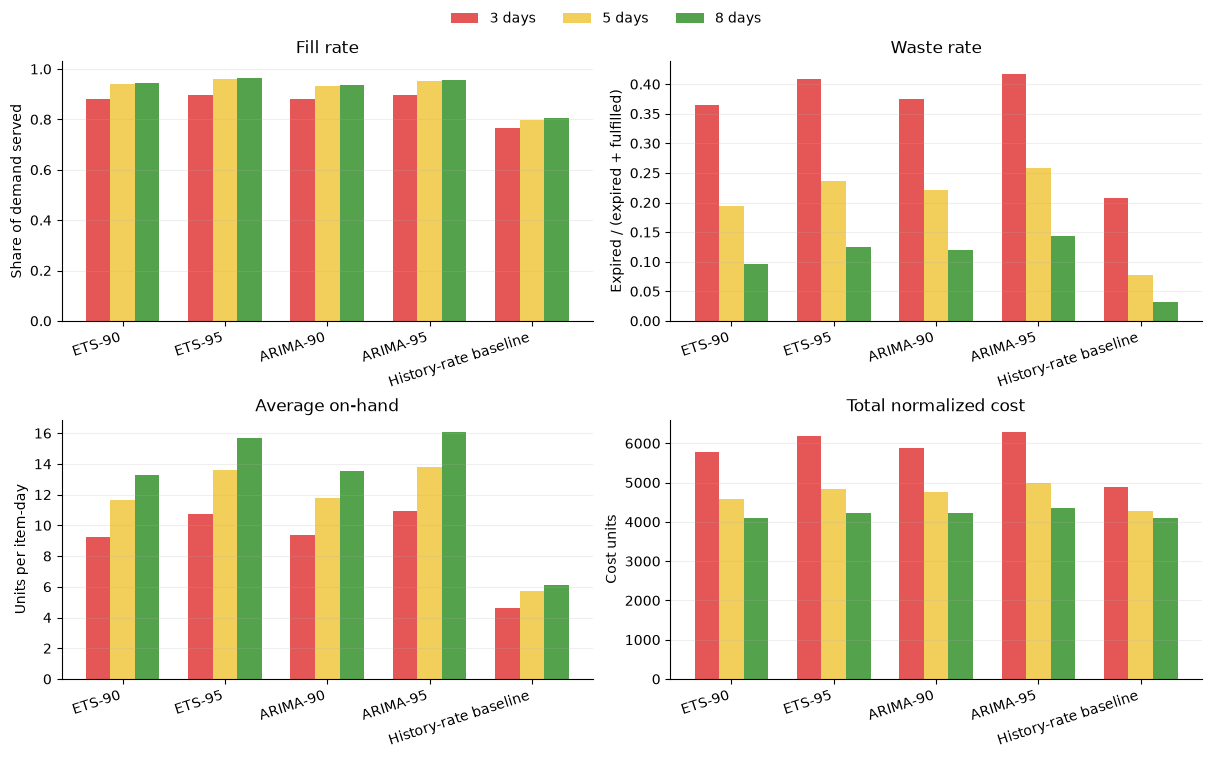

In [21]:
# Fix category order and colors so every panel has the same visual grammar.
strategy_order = ["ETS-90", "ETS-95", "ARIMA-90", "ARIMA-95", "History-rate baseline"]
shelf_order = list(shelf_lives)
shelf_colors = ["#E45756", "#F2CF5B", "#54A24B"]

fig, axes = plt.subplots(2, 2, figsize=(12, 7.5), layout="constrained")
specs = [
    ("fill_rate", "Fill rate", "Share of demand served"),
    ("waste_outflow_rate", "Waste rate", "Expired / (expired + fulfilled)"),
    ("avg_on_hand", "Average on-hand", "Units per item-day"),
    ("total_cost", "Total normalized cost", "Cost units"),
]
x, width = np.arange(len(strategy_order)), 0.24
for ax, (column, title, ylabel) in zip(axes.flat, specs):
    for offset, (shelf_name, color) in enumerate(zip(shelf_order, shelf_colors)):
        # Reindex prevents a DataFrame row order from changing bar positions.
        values = (portfolio[portfolio["shelf_life"].eq(shelf_name)]
                  .set_index("strategy").reindex(strategy_order)[column])
        # Offsets place the three shelf lives side by side for each strategy.
        ax.bar(x + (offset - 1) * width, values, width,
               label=shelf_name, color=color)
    ax.set(title=title, ylabel=ylabel)
    ax.set_xticks(x, strategy_order, rotation=18, ha="right")
    ax.grid(axis="y", alpha=.2)
    ax.spines[["top", "right"]].set_visible(False)
axes[0, 0].set_ylim(0, 1.03)
fig.legend(*axes[0, 0].get_legend_handles_labels(), ncol=3,
           loc="outside upper center", frameon=False)
plt.show()

Total cost combines components with different meanings, so we also show the decomposition. Purchase cost is charged on ordered units, holding cost on ending unit-days, shortage cost on lost units, ordering cost on positive SKU order lines, and waste cost on expired units.

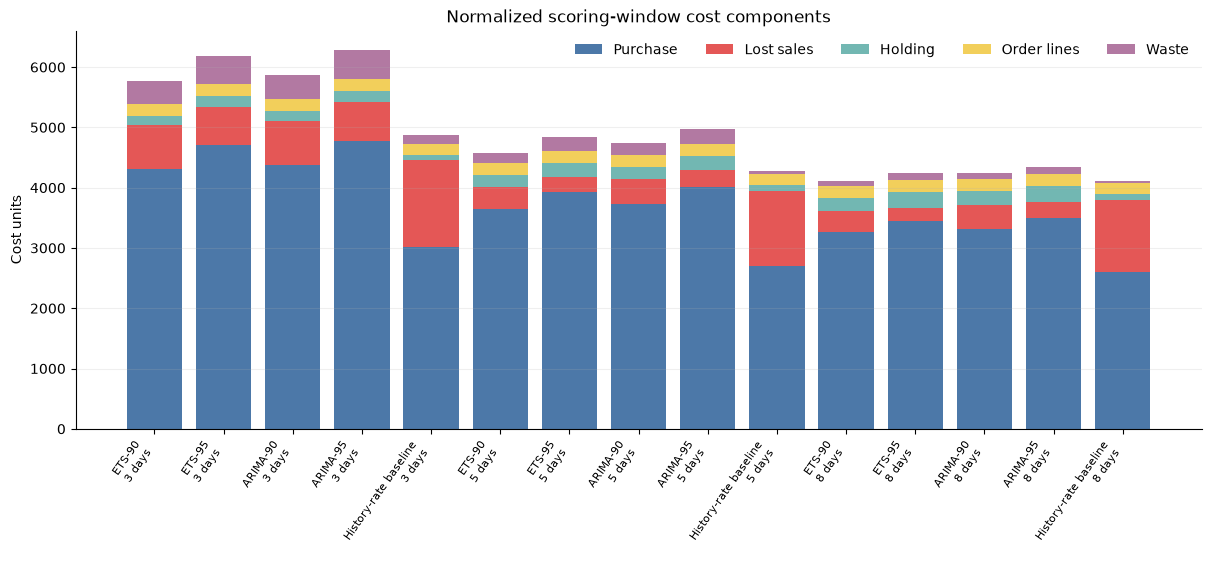

In [22]:
cost_columns = ["purchase_cost", "shortage_cost", "holding_cost", "ordering_cost", "waste_cost"]
cost_labels = ["Purchase", "Lost sales", "Holding", "Order lines", "Waste"]
cost_colors = ["#4C78A8", "#E45756", "#72B7B2", "#F2CF5B", "#B279A2"]

# Sort into three shelf-life blocks, each with the same strategy order.
ordered = portfolio.assign(
    shelf_rank=lambda x: x["shelf_life"].map({v: i for i, v in enumerate(shelf_order)}),
    strategy_rank=lambda x: x["strategy"].map({v: i for i, v in enumerate(strategy_order)}),
).sort_values(["shelf_rank", "strategy_rank"])
labels = [f"{r.strategy}\n{r.shelf_life}" for r in ordered.itertuples()]

fig, ax = plt.subplots(figsize=(12, 5.5), layout="constrained")
# `bottom` accumulates prior components to build stacked bars.
bottom = np.zeros(len(ordered))
for column, label, color in zip(cost_columns, cost_labels, cost_colors):
    values = ordered[column].to_numpy()
    ax.bar(range(len(ordered)), values, bottom=bottom, label=label, color=color)
    bottom += values
ax.set(title="Normalized scoring-window cost components", ylabel="Cost units")
ax.set_xticks(range(len(labels)), labels, rotation=55, ha="right", fontsize=8)
ax.grid(axis="y", alpha=.2)
ax.legend(ncol=5, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

Portfolio averages can conceal item-level differences. These boxplots hold the strategy fixed at ETS-95 and show how the shelf-life assumption changes the distribution across the 20 items.

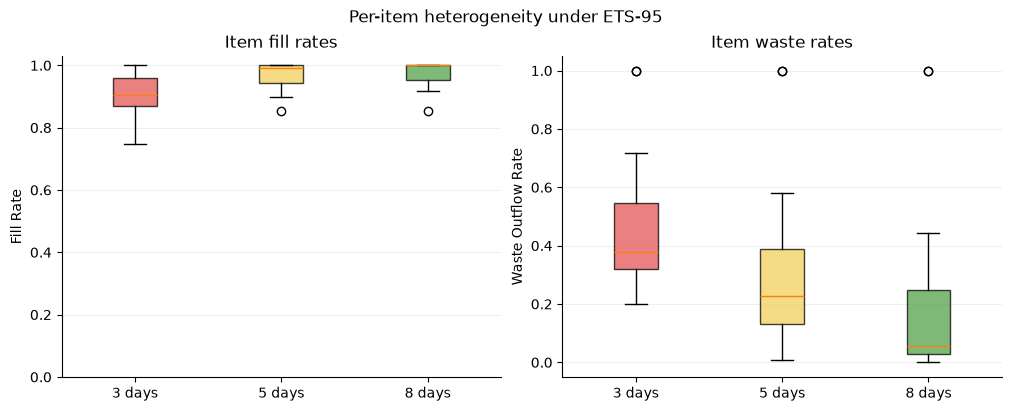

In [23]:
# Hold the policy fixed so the boxplots isolate shelf-life differences.
ets95_items = by_item[by_item["strategy"].eq("ETS-95")]
fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
for ax, metric, title in [
    (axes[0], "fill_rate", "Item fill rates"),
    (axes[1], "waste_outflow_rate", "Item waste rates"),
]:
    # Each box contains the same 20 items under one shelf-life run.
    values = [ets95_items[ets95_items["shelf_life"].eq(name)][metric]
              for name in shelf_order]
    boxes = ax.boxplot(values, tick_labels=shelf_order, patch_artist=True)
    for patch, color in zip(boxes["boxes"], shelf_colors):
        patch.set_facecolor(color)
        patch.set_alpha(.75)
    ax.set(title=title, ylabel=metric.replace("_", " ").title())
    ax.grid(axis="y", alpha=.2)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylim(0, 1.03)
fig.suptitle("Per-item heterogeneity under ETS-95")
plt.show()

In [24]:
# A compact diagnostic view of the lowest-fill items in the harshest scenario.
lowest_fill = (by_item[(by_item["strategy"].eq("ETS-95"))
                       & (by_item["shelf_life"].eq("3 days"))]
               .sort_values(["fill_rate", "waste_outflow_rate"])
               .head(6))
print(lowest_fill[["unique_id", "fill_rate", "lost_sales_units",
                   "avg_on_hand", "expired_units", "waste_outflow_rate"]]
      .round(3).to_string(index=False))

       unique_id  fill_rate  lost_sales_units  avg_on_hand  expired_units  waste_outflow_rate
FOODS_1_040_CA_1      0.748              29.0        5.048           47.0               0.353
FOODS_1_032_CA_1      0.769              15.0       11.143          128.0               0.719
FOODS_1_094_CA_1      0.821               7.0        6.143           73.0               0.695
FOODS_1_083_CA_1      0.844               7.0        8.167           90.0               0.703
FOODS_1_018_CA_1      0.850              61.0       15.810           96.0               0.217
FOODS_1_082_CA_1      0.876              48.0       16.452          107.0               0.240


## 8. Read the event paths

Finally, compare the same two items and the same ETS-95 policy under 3- and 8-day shelf lives. Lines show demand and ending stock; markers keep orders, receipts, expiry, and shortages visually distinct. The pale band is the 42-day scoring window.

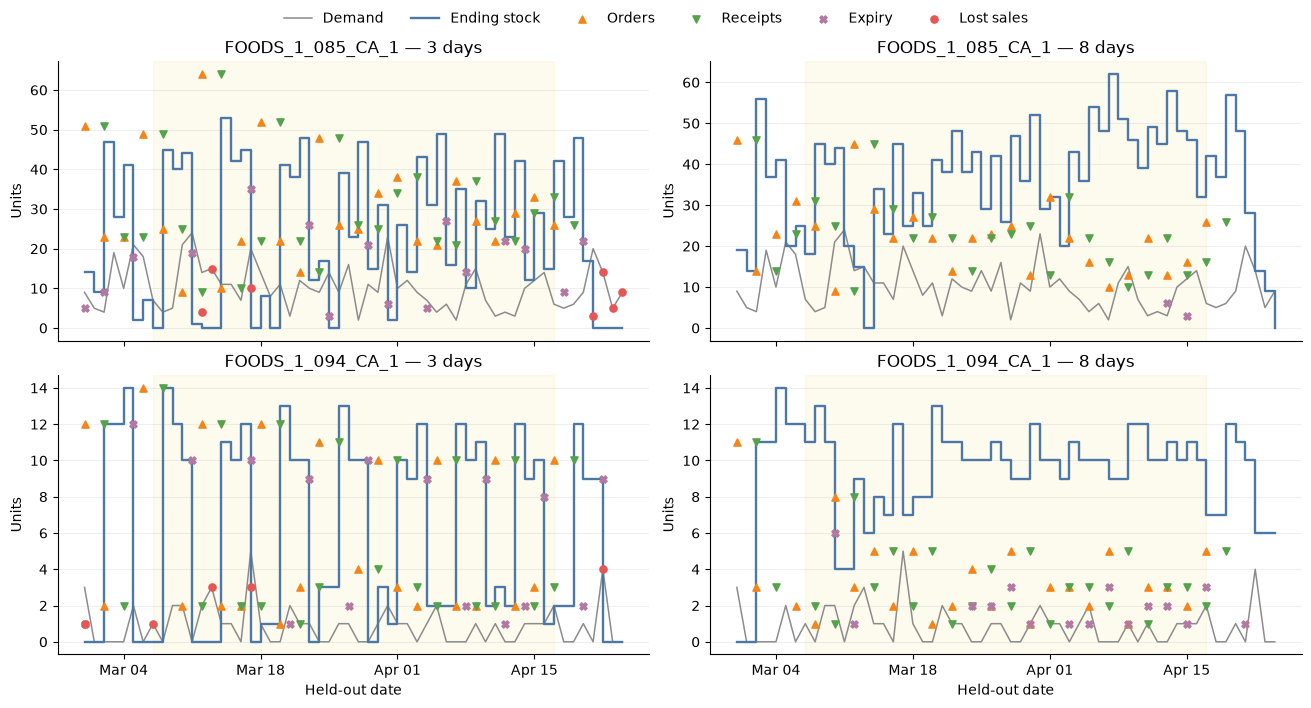

In [25]:
# Compare fixed selection ranks under the shortest and longest shelf lives.
detail_items = [representative_items[0], representative_items[2]]
detail_shelves = ["3 days", "8 days"]
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True, layout="constrained")

for row, item in enumerate(detail_items):
    for column, shelf_name in enumerate(detail_shelves):
        ax = axes[row, column]
        events = results[(shelf_name, "ETS-95")].to_event_frame(window="all")
        events = events.query("event_type == 'period' and unique_id == @item").sort_values("date")
        # Lines show daily demand and state; markers below show discrete flows.
        ax.plot(events["date"], events["demand"], color="0.55", lw=1.1, label="Demand")
        ax.step(events["date"], events["ending_on_hand"], where="post",
                color="#4C78A8", lw=1.7, label="Ending stock")

        for field, marker, color, label in [
            ("order_quantity", "^", "#F58518", "Orders"),
            ("received_units", "v", "#54A24B", "Receipts"),
            ("expired_units", "X", "#B279A2", "Expiry"),
            ("shortage_units", "o", "#E45756", "Lost sales"),
        ]:
            # Plot only positive flows so zero-valued markers do not obscure the paths.
            positive = events[events[field] > 0]
            ax.scatter(positive["date"], positive[field], marker=marker,
                       color=color, s=27, zorder=3, label=label)

        # Shade the exact dates used by InventoryEvaluator above.
        scoring_start = holdout_start + pd.Timedelta(days=warmup_periods)
        scoring_end = scoring_start + pd.Timedelta(days=scoring_periods - 1)
        ax.axvspan(scoring_start, scoring_end, color="#F2CF5B", alpha=.10)
        ax.set(title=f"{item} — {shelf_name}", ylabel="Units")
        ax.grid(axis="y", alpha=.2)
        ax.spines[["top", "right"]].set_visible(False)
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=14))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

for ax in axes[-1]:
    ax.set_xlabel("Held-out date")
fig.legend(*axes[0, 0].get_legend_handles_labels(), ncol=6,
           loc="outside upper center", frameon=False)
plt.show()

## What this experiment shows

The figures and tables are conditional outcomes for these 20 history-selected demand series, this single forecast origin, fixed targets, and the displayed hypothetical retail assumptions.

- Within a model and shelf life, 90% versus 95% is a controlled probability contrast.
- Within a strategy, changing shelf life isolates the engine's shelf-life assumption.
- ETS versus ARIMA changes the fitted model; comparison with the baseline also changes the information source.
- Expiry is not ordinary demand depletion: it is a separately recorded stock outflow before demand.

No result establishes a universally superior model, probability, policy, or shelf life. A rolling retail deployment would also need refreshed forecasts, calibrated costs, real product shelf lives, and operational data beyond M5 demand observations.